# Blinkit Retail Sales Analysis

### A data-driven exploration of product mix, outlet performance, and retail sales drivers

**Project type:** Portfolio case study  \n**Tools:** Python, Pandas, Matplotlib, Seaborn, Jupyter Notebook  \n**Dataset:** Item-level outlet sales extract

> **Objective:** Convert raw retail sales data into a clear, decision-oriented analysis that highlights category demand, outlet performance, location patterns, and data-quality considerations.

## Executive Summary

This notebook profiles a retail item-outlet dataset and translates the results into business-facing findings. The workflow covers data loading, quality checks, category standardisation, KPI calculation, comparative analysis, and visual storytelling.

The analysis is intentionally transparent: missing item-weight values are reported rather than silently imputed, and the dataset is treated as an educational extract rather than a live Blinkit performance feed.

## 1. Environment Setup and Data Loading

The first section imports the analytical libraries, applies a consistent visual theme, and loads the CSV from the repository root. Keeping the data path relative makes the notebook easy to reproduce after cloning the project.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Reproducible, portfolio-friendly chart styling
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "font.size": 10
})

DATA_PATH = Path("blinkit_data.csv")
IMAGE_DIR = Path("images")
IMAGE_DIR.mkdir(exist_ok=True)

raw = pd.read_csv(DATA_PATH)
raw.shape

Matplotlib is building the font cache; this may take a moment.


(8523, 12)

In [2]:
# Standardise column names for reliable, readable analysis
df = raw.copy()
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_", regex=False)
)

# Harmonise inconsistent labels without changing the underlying sales values
df["item_fat_content"] = df["item_fat_content"].replace({
    "LF": "Low Fat",
    "low fat": "Low Fat",
    "reg": "Regular"
})

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
display(df.head(5))

Rows: 8,523
Columns: 12


,item_fat_content,item_identifier,item_type,outlet_establishment_year,outlet_identifier,outlet_location_type,outlet_size,outlet_type,item_visibility,item_weight,sales,rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


## 2. Data Quality Review

Before interpreting the charts, the dataset is checked for duplicates, missing values, data types, and invalid sales values. This is important because analytical conclusions are only as reliable as the data preparation behind them.

In [3]:
quality = pd.DataFrame({
    "metric": [
        "Rows", "Columns", "Duplicate rows", "Missing cells",
        "Missing item weights", "Negative sales records"
    ],
    "value": [
        len(df),
        df.shape[1],
        int(df.duplicated().sum()),
        int(df.isna().sum().sum()),
        int(df["item_weight"].isna().sum()),
        int((df["sales"] < 0).sum())
    ]
})
display(quality)

missing = (
    df.isna().sum()
      .rename("missing_values")
      .to_frame()
      .query("missing_values > 0")
      .sort_values("missing_values", ascending=False)
)
print("Columns with missing values:")
display(missing)

,metric,value
0,Rows,8523
1,Columns,12
2,Duplicate rows,0
3,Missing cells,1463
4,Missing item weights,1463
5,Negative sales records,0


Columns with missing values:


,missing_values
item_weight,1463


## 3. KPI Snapshot

These headline measures provide a quick view of the dataset before the deeper category and outlet comparisons.

In [4]:
total_sales = df["sales"].sum()
avg_sales = df["sales"].mean()
avg_rating = df["rating"].mean()
top_item = df.groupby("item_type")["sales"].sum().idxmax()
top_item_sales = df.groupby("item_type")["sales"].sum().max()
top_outlet = df.groupby("outlet_type")["sales"].sum().idxmax()
top_outlet_sales = df.groupby("outlet_type")["sales"].sum().max()

kpis = pd.DataFrame({
    "KPI": [
        "Total sales (dataset units)", "Average sale / record", "Average rating",
        "Top item category", "Top outlet format"
    ],
    "Value": [
        f"{total_sales:,.2f}", f"{avg_sales:,.2f}", f"{avg_rating:.2f} / 5",
        f"{top_item} ({top_item_sales:,.2f})",
        f"{top_outlet} ({top_outlet_sales:,.2f})"
    ]
})
display(kpis)

,KPI,Value
0,Total sales (dataset units),"1,201,681.48"
1,Average sale / record,140.99
2,Average rating,3.97 / 5
3,Top item category,"Fruits and Vegetables (178,124.08)"
4,Top outlet format,"Supermarket Type1 (787,549.89)"


## 4. Sales Mix by Fat Content

This view compares total sales across the standardised fat-content segments. A bar chart is used instead of a pie chart so that the difference between segments can be read more accurately.

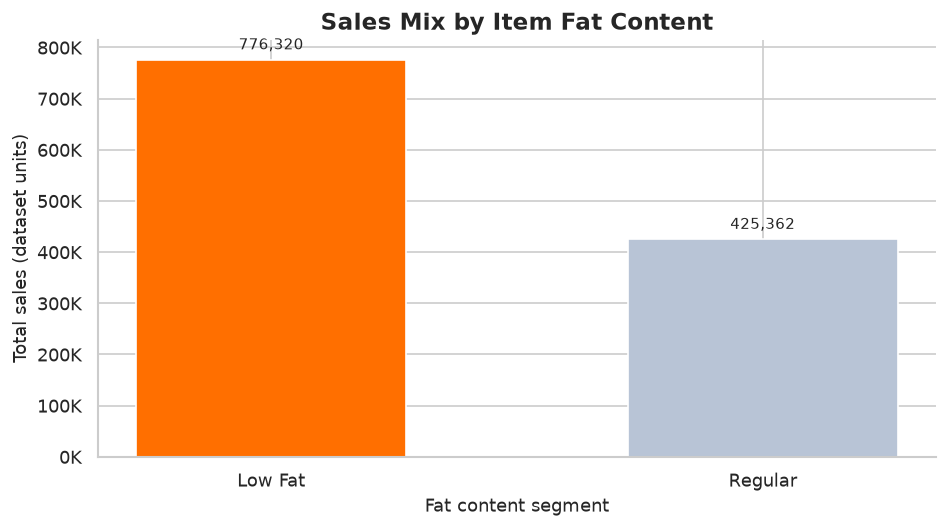

,item_fat_content,sales,share
0,Low Fat,"776,319.68",64.6%
1,Regular,"425,361.80",35.4%


In [5]:
fat_sales = (
    df.groupby("item_fat_content", as_index=False)["sales"]
      .sum()
      .sort_values("sales", ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#FF6F00" if x == fat_sales.iloc[0]["item_fat_content"] else "#B8C4D6" for x in fat_sales["item_fat_content"]]
bars = ax.bar(fat_sales["item_fat_content"], fat_sales["sales"], color=colors, width=0.55)
ax.set_title("Sales Mix by Item Fat Content")
ax.set_xlabel("Fat content segment")
ax.set_ylabel("Total sales (dataset units)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
ax.bar_label(bars, labels=[f"{v:,.0f}" for v in fat_sales["sales"]], padding=4, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "sales_by_fat_content.png", bbox_inches="tight")
plt.show()

fat_share = fat_sales.assign(share=fat_sales["sales"] / total_sales * 100)
display(fat_share.style.format({"sales": "{:,.2f}", "share": "{:.1f}%"}))

## 5. Sales by Item Category

The category ranking identifies which product groups contribute most to observed sales. This is useful for assortment reviews, promotional planning, and prioritising category-level follow-up.

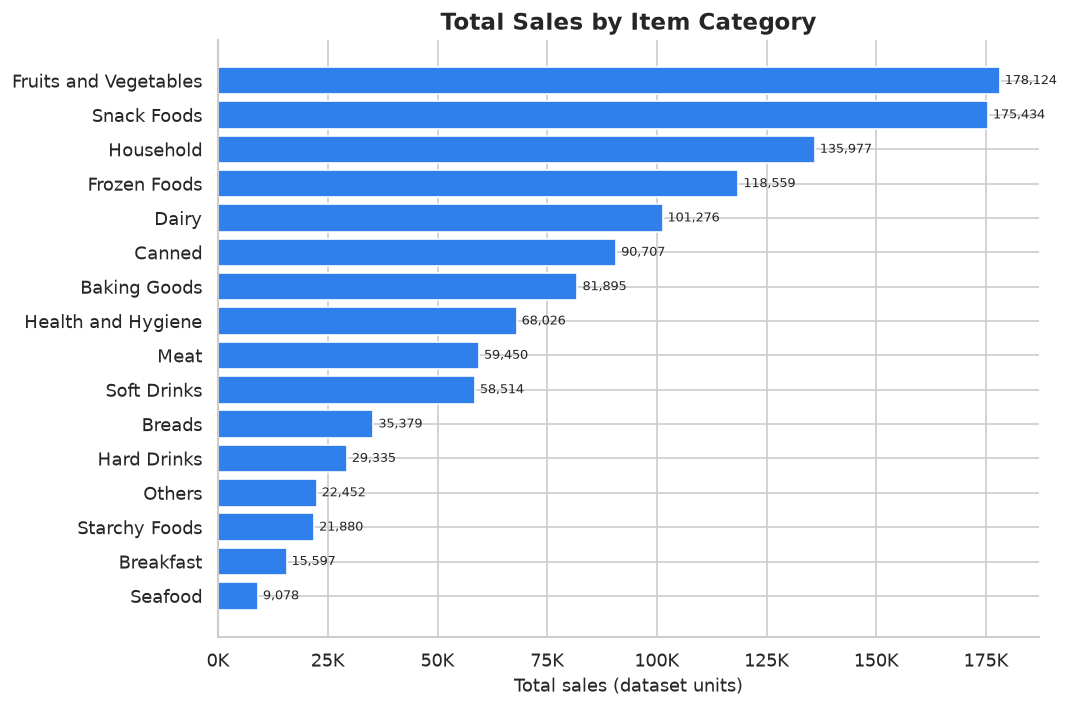

Leading category: Fruits and Vegetables with 178,124.08 in observed sales.


In [6]:
category_sales = (
    df.groupby("item_type", as_index=False)["sales"]
      .sum()
      .sort_values("sales", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(category_sales["item_type"], category_sales["sales"], color="#2F80ED")
ax.set_title("Total Sales by Item Category")
ax.set_xlabel("Total sales (dataset units)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
ax.bar_label(bars, labels=[f"{v:,.0f}" for v in category_sales["sales"]], padding=3, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "sales_by_item_category.png", bbox_inches="tight")
plt.show()

print(f"Leading category: {top_item} with {top_item_sales:,.2f} in observed sales.")

## 6. Outlet Format Performance

Outlet format is compared using total sales and average sale per record. Looking at both measures prevents a large record count from being mistaken for stronger per-record performance.

,total_sales,avg_sale,records
outlet_type,,,
Supermarket Type1,"787,549.89",141.21,"5,577"
Grocery Store,"151,939.15",140.29,"1,083"
Supermarket Type2,"131,477.77",141.68,928
Supermarket Type3,"130,714.67",139.80,935


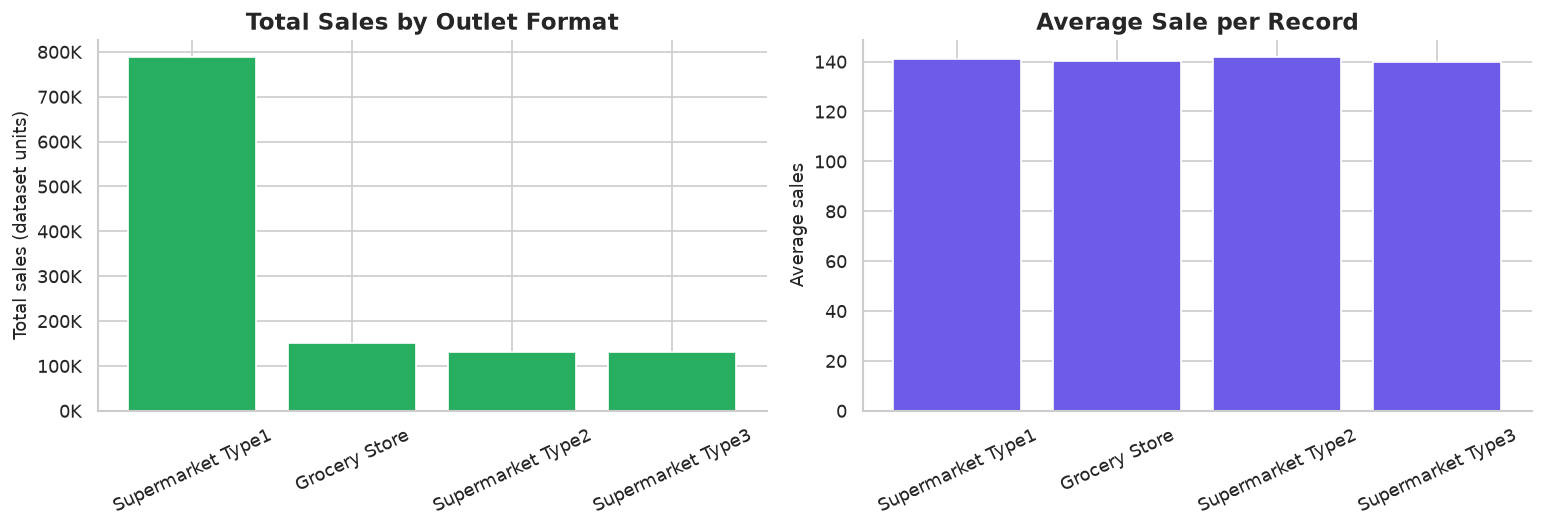

In [7]:
outlet_summary = (
    df.groupby("outlet_type")
      .agg(total_sales=("sales", "sum"), avg_sale=("sales", "mean"), records=("sales", "size"))
      .sort_values("total_sales", ascending=False)
)
display(outlet_summary.style.format({
    "total_sales": "{:,.2f}", "avg_sale": "{:,.2f}", "records": "{:,.0f}"
}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_df = outlet_summary.reset_index()
axes[0].bar(plot_df["outlet_type"], plot_df["total_sales"], color="#27AE60")
axes[0].set_title("Total Sales by Outlet Format")
axes[0].set_ylabel("Total sales (dataset units)")
axes[0].tick_params(axis="x", rotation=25)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
axes[1].bar(plot_df["outlet_type"], plot_df["avg_sale"], color="#6C5CE7")
axes[1].set_title("Average Sale per Record")
axes[1].set_ylabel("Average sales")
axes[1].tick_params(axis="x", rotation=25)
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "outlet_format_performance.png", bbox_inches="tight")
plt.show()

## 7. Outlet Location Tier and Fat-Content Mix

The grouped comparison shows whether the product mix differs across outlet location tiers. This helps separate overall sales scale from the composition of sales.

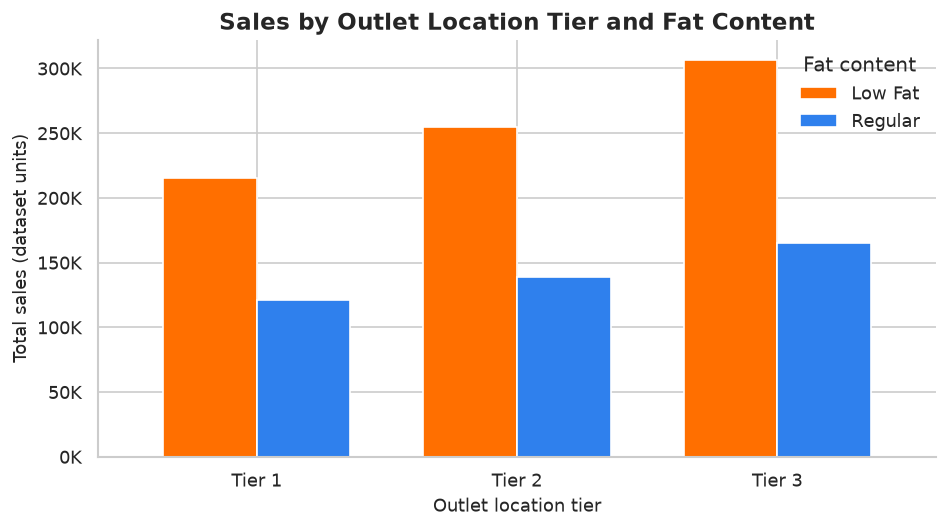

item_fat_content,Low Fat,Regular
outlet_location_type,,
Tier 1,"215,048","121,350"
Tier 2,"254,465","138,686"
Tier 3,"306,807","165,326"


In [8]:
tier_mix = (
    df.pivot_table(index="outlet_location_type", columns="item_fat_content", values="sales", aggfunc="sum", fill_value=0)
      .sort_index()
)

ax = tier_mix.plot(kind="bar", figsize=(8, 4.5), color=["#FF6F00", "#2F80ED"], width=0.72)
ax.set_title("Sales by Outlet Location Tier and Fat Content")
ax.set_xlabel("Outlet location tier")
ax.set_ylabel("Total sales (dataset units)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
ax.legend(title="Fat content", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "tier_fat_content_mix.png", bbox_inches="tight")
plt.show()

display(tier_mix.style.format("{:,.0f}"))

## 8. Sales by Outlet Establishment Year

The time-based view uses outlet establishment year as a cohort dimension. It does not represent monthly or daily sales trends; rather, it shows how the sales extract is distributed across outlet cohorts.

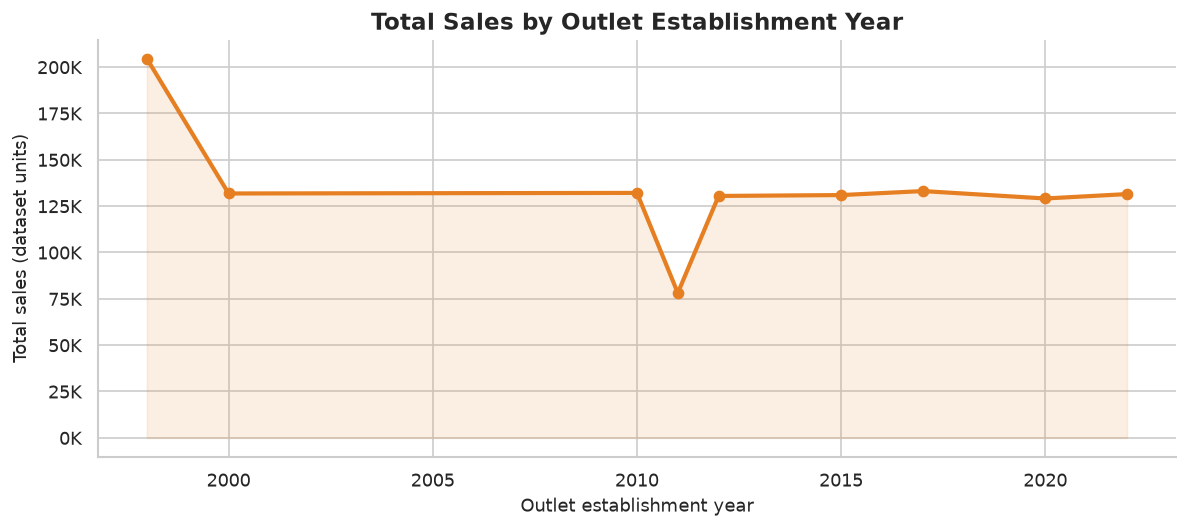

In [9]:
year_sales = (
    df.groupby("outlet_establishment_year", as_index=False)["sales"]
      .sum()
      .sort_values("outlet_establishment_year")
)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(year_sales["outlet_establishment_year"], year_sales["sales"], marker="o", linewidth=2.5, color="#E67E22")
ax.fill_between(year_sales["outlet_establishment_year"], year_sales["sales"], alpha=0.12, color="#E67E22")
ax.set_title("Total Sales by Outlet Establishment Year")
ax.set_xlabel("Outlet establishment year")
ax.set_ylabel("Total sales (dataset units)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "sales_by_establishment_year.png", bbox_inches="tight")
plt.show()

## 9. Sales by Outlet Size and Location Tier

These comparisons add operational context to the outlet analysis. They show how observed sales are distributed across outlet-size categories and location tiers.

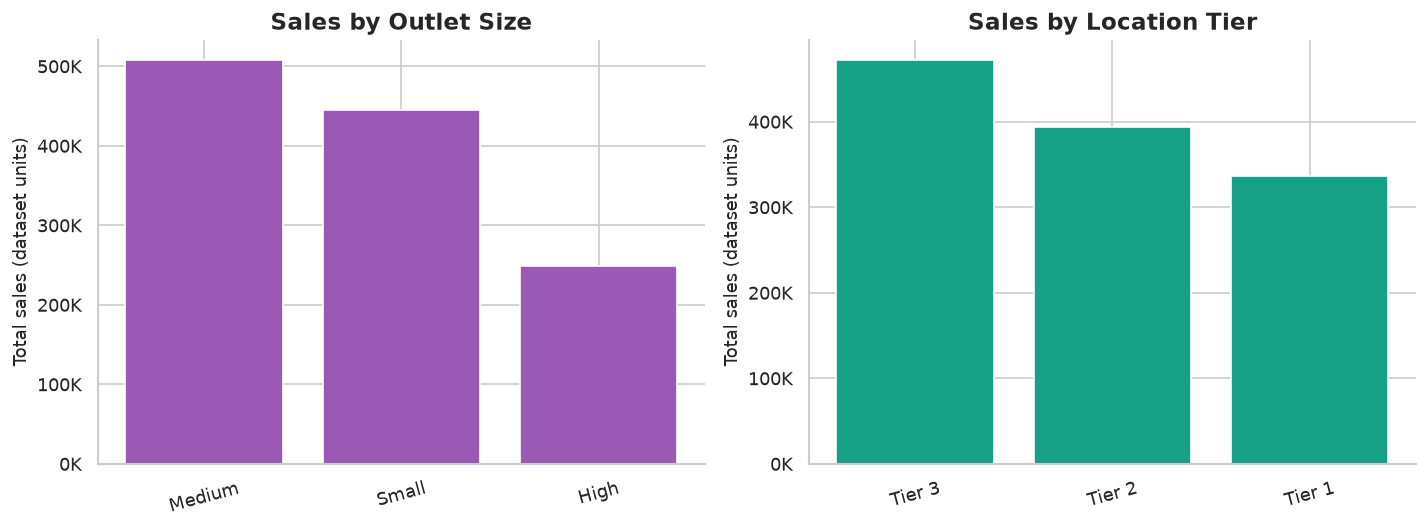

,outlet_size,sales
1,Medium,"507,895.73"
2,Small,"444,794.17"
0,High,"248,991.58"


,outlet_location_type,sales
2,Tier 3,"472,133.03"
1,Tier 2,"393,150.64"
0,Tier 1,"336,397.81"


In [10]:
size_sales = df.groupby("outlet_size", as_index=False)["sales"].sum().sort_values("sales", ascending=False)
tier_sales = df.groupby("outlet_location_type", as_index=False)["sales"].sum().sort_values("sales", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(size_sales["outlet_size"], size_sales["sales"], color="#9B59B6")
axes[0].set_title("Sales by Outlet Size")
axes[0].set_ylabel("Total sales (dataset units)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
axes[1].bar(tier_sales["outlet_location_type"], tier_sales["sales"], color="#16A085")
axes[1].set_title("Sales by Location Tier")
axes[1].set_ylabel("Total sales (dataset units)")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "outlet_size_and_tier.png", bbox_inches="tight")
plt.show()

display(size_sales.style.format({"sales": "{:,.2f}"}))
display(tier_sales.style.format({"sales": "{:,.2f}"}))

## 10. Relationship Between Item Visibility and Sales

The scatter plot explores whether item visibility is associated with record-level sales. The chart is descriptive, not causal: a relationship in this extract should not be interpreted as proof that visibility directly drives sales.

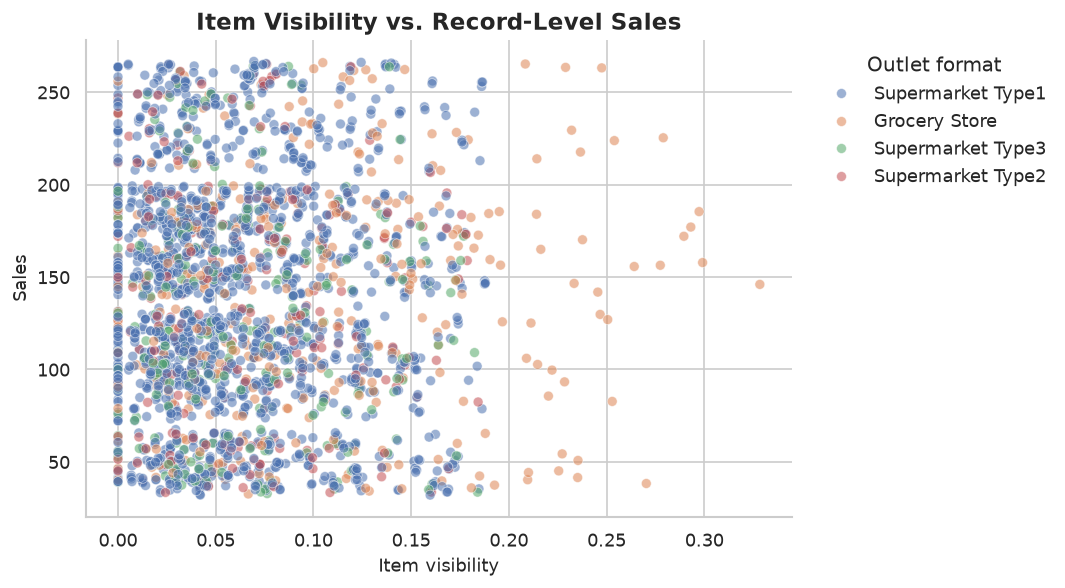

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
sample = df.sample(min(2500, len(df)), random_state=42)
sns.scatterplot(data=sample, x="item_visibility", y="sales", hue="outlet_type", alpha=0.55, s=35, ax=ax)
ax.set_title("Item Visibility vs. Record-Level Sales")
ax.set_xlabel("Item visibility")
ax.set_ylabel("Sales")
ax.legend(title="Outlet format", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "visibility_vs_sales.png", bbox_inches="tight")
plt.show()

## 11. Key Business Insights

The following statements are generated from the cleaned dataset and are intended to guide portfolio discussion. They describe observed patterns rather than current company performance.

In [12]:
top_fat = fat_sales.iloc[0]
top_tier = tier_sales.iloc[0]
top_size = size_sales.iloc[0]

insights = [
    f"**Category leader:** {top_item} contributes {top_item_sales:,.2f} in observed sales, making it the leading item category in this extract.",
    f"**Outlet leader:** {top_outlet} is the highest-sales outlet format with {top_outlet_sales:,.2f} in observed sales.",
    f"**Fat-content mix:** {top_fat['item_fat_content']} represents {top_fat['sales'] / total_sales * 100:.1f}% of total observed sales.",
    f"**Location pattern:** {top_tier['outlet_location_type']} is the highest-sales location tier with {top_tier['sales']:,.2f}.",
    f"**Data-quality note:** {int(df['item_weight'].isna().sum()):,} item-weight values are missing; weight-based analysis should document its exclusion or imputation policy."
]
for item in insights:
    display(Markdown(f"- {item}"))

- **Category leader:** Fruits and Vegetables contributes 178,124.08 in observed sales, making it the leading item category in this extract.

- **Outlet leader:** Supermarket Type1 is the highest-sales outlet format with 787,549.89 in observed sales.

- **Fat-content mix:** Low Fat represents 64.6% of total observed sales.

- **Location pattern:** Tier 3 is the highest-sales location tier with 472,133.03.

- **Data-quality note:** 1,463 item-weight values are missing; weight-based analysis should document its exclusion or imputation policy.

## 12. Limitations and Reproducibility

This is an educational item-outlet sales extract, not a live internal Blinkit reporting feed. The dataset contains missing item-weight values, and the available fields do not establish causality, profitability, delivery performance, customer retention, or time-series growth.

To reproduce the analysis, install the packages in `requirements.txt`, place the CSV beside this notebook, and run the cells from top to bottom. All chart files are saved under `images/` for use in a portfolio or project README.